<a href="https://colab.research.google.com/github/keerthi5536/deep-learing/blob/main/AND_Gate_with_Trained_Weight_(Single_Perceptron).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial weights: [-0.1280102  -0.94814754]
Initial bias: 0.0

Training Single Perceptron (AND gate)
Iteration 0 : loss = 0.4983
Iteration 1000 : loss = 0.3958
Iteration 2000 : loss = 0.3335

Training complete
Final weights: w1 = 1.211, w2 = 1.118
Final bias = -1.971

Predictions (AND Gate)
Input [0 0] -> Pred = 0.122 (0)
Input [0 1] -> Pred = 0.299 (0)
Input [1 0] -> Pred = 0.319 (0)
Input [1 1] -> Pred = 0.588 (1)


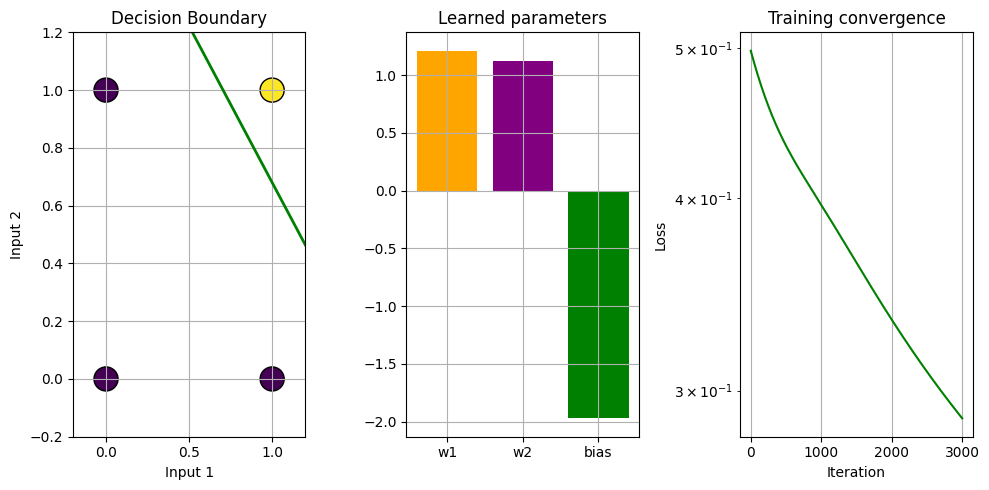


Point position relative to boundary
[0 0] -> -1.971 -> Below (class0)
[0 1] -> -0.853 -> Below (class0)
[1 0] -> -0.760 -> Below (class0)
[1 1] -> 0.358 -> Above (class1)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# AND gate data
x = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [0],
              [0],
              [1]])

np.random.seed(2)

# initialize weights
weights = np.random.uniform(-1,1,(input_size,1))
bias = np.array([[0.0]])

print("Initial weights:", weights.flatten())
print("Initial bias:", bias[0,0])


# sigmoid
def sigmoid(x):
    return 1/(1+np.exp(-np.clip(x,-250,250)))


def sigmoid_derivative(x):
    return x*(1-x)


# prediction
def predict(x,weights,bias):
    linear = np.dot(x,weights)+bias
    return sigmoid(linear)


print("\nTraining Single Perceptron (AND gate)")

loss_history = []

for iteration in range(iterations):

    linear_output = np.dot(x,weights)+bias
    output = sigmoid(linear_output)

    error = y - output

    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(x.T,d_output)
    bias += learning_rate * np.sum(d_output,axis=0,keepdims=True)

    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration} : loss = {current_loss:.4f}")


print("\nTraining complete")

print(f"Final weights: w1 = {weights[0,0]:.3f}, w2 = {weights[1,0]:.3f}")
print(f"Final bias = {bias[0,0]:.3f}")


# predictions
final_predictions = predict(x,weights,bias)

print("\nPredictions (AND Gate)")

for i in range(len(x)):

    pred = final_predictions[i,0]

    if pred > 0.5:
        cls = 1
    else:
        cls = 0

    print(f"Input {x[i]} -> Pred = {pred:.3f} ({cls})")


# ------------------------
# Plot decision boundary
# ------------------------

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)

plt.scatter(x[:,0],x[:,1],
            c=y.flatten(),
            s=300,
            edgecolors='black')

w1 = weights[0,0]
w2 = weights[1,0]
b = bias[0,0]

x1 = np.linspace(-0.2,1.2,100)

if abs(w2) > 1e-6:
    x2 = (-w1*x1 - b)/w2
    plt.plot(x1,x2,'g',linewidth=2,label="Decision boundary")

plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Decision Boundary")
plt.grid(True)


# parameters plot
plt.subplot(1,3,2)

params = ['w1','w2','bias']
values = [weights[0,0],weights[1,0],bias[0,0]]

plt.bar(params,values,color=['orange','purple','green'])

plt.title("Learned parameters")
plt.grid(True)


# loss plot
plt.subplot(1,3,3)

plt.semilogy(loss_history,'g')

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training convergence")
plt.grid(True)

plt.tight_layout()
plt.show()


# verification

print("\nPoint position relative to boundary")

for i in range(len(x)):

    val = weights[0,0]*x[i,0] + weights[1,0]*x[i,1] + bias[0,0]

    if val > 0:
        side = "Above (class1)"
    else:
        side = "Below (class0)"

    print(f"{x[i]} -> {val:.3f} -> {side}")